<a href="https://colab.research.google.com/github/febriyansyah-id/COLLAB/blob/main/notebooks/nlp/NLP-assignment-P04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP Assignment P04
## Feature Extraction / Ekstraksi Fitur

Notebook ini digunakan di Google Colab untuk mengubah corpus teks menjadi fitur numerik menggunakan Bag of Words dan TF-IDF, kemudian mencari dokumen yang paling mirip dengan cosine similarity.

## Tujuan

1. Melakukan preprocessing pada corpus.
2. Membuat matriks Bag of Words.
3. Membuat matriks TF-IDF.
4. Menghitung cosine similarity untuk sebuah query.
5. Menganalisis perbedaan fitur sparse dan embedding.

## Konsep dan deskripsi metode

### Bag of Words (BoW)
BoW mengubah dokumen menjadi vektor berdasarkan jumlah kemunculan setiap kata. Contoh: corpus `['saya belajar NLP', 'saya belajar Python']` memiliki vocabulary `['belajar', 'nlp', 'python', 'saya']`. Dokumen pertama direpresentasikan sebagai `[1, 1, 0, 1]`. BoW sederhana dan mudah diinterpretasikan, tetapi tidak memahami urutan atau makna kata.

### TF-IDF
TF-IDF (*Term Frequency–Inverse Document Frequency*) memberi bobot pada kata berdasarkan frekuensinya dalam satu dokumen dan kelangkaannya di seluruh corpus. Kata yang muncul di banyak dokumen mendapat bobot lebih rendah, sedangkan kata yang spesifik pada dokumen mendapat bobot lebih tinggi. Contoh: jika `data` muncul pada satu dokumen tetapi tidak pada dokumen lain, nilai TF-IDF `data` pada dokumen tersebut menjadi relatif tinggi.

### Cosine similarity
Cosine similarity mengukur kedekatan arah dua vektor dengan nilai umumnya antara 0 dan 1 untuk fitur non-negatif. Nilai mendekati 1 berarti dokumen memiliki fitur yang mirip, sedangkan nilai mendekati 0 berarti tidak banyak fitur yang sama. Metode ini digunakan untuk mencari dokumen yang paling relevan dengan query.

### Word embedding
Word embedding merepresentasikan kata sebagai vektor dense. Kata yang memiliki konteks serupa diharapkan memiliki posisi yang berdekatan, misalnya `dokter` dan `rumah sakit`. Berbeda dari BoW dan TF-IDF, embedding dapat menangkap kemiripan semantik.

### Transformer embedding
Transformer embedding menggunakan model seperti BERT untuk menghasilkan representasi yang mempertimbangkan konteks kalimat. Kata yang sama dapat memiliki vektor berbeda ketika digunakan dalam konteks berbeda. Metode ini lebih kuat, tetapi membutuhkan model dan komputasi lebih besar.

### Preprocessing
Preprocessing membersihkan dan menormalkan teks sebelum feature extraction. Contohnya lowercasing, penghapusan tanda baca, tokenisasi, dan stopword removal. Tahap ini memengaruhi vocabulary serta nilai BoW dan TF-IDF.

## 1. Instalasi dan import library

Google Colab biasanya sudah menyediakan NumPy, pandas, dan scikit-learn.

In [1]:
%pip install -q numpy pandas scikit-learn matplotlib seaborn

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print('NumPy:', np.__version__)
print('pandas:', pd.__version__)

NumPy: 2.1.3
pandas: 2.2.3


## 2. Menyiapkan corpus

Corpus terdiri dari 10 dokumen pendek tentang Python, data science, machine learning, dan AI.

In [3]:
sentences = [
    'Saya suka belajar data science.',
    'Python adalah bahasa pemrograman yang populer.',
    'Saya menggunakan Python untuk analisis data.',
    'Analisis data membantu dalam pengambilan keputusan.',
    'Machine learning adalah cabang dari kecerdasan buatan.',
    'Algoritma machine learning dapat memprediksi hasil.',
    'Saya tertarik pada teknologi baru.',
    'Kecerdasan buatan memiliki banyak aplikasi.',
    'Belajar data science sangat menarik.',
    'Saya mengikuti kursus online tentang machine learning.',
]

corpus = pd.DataFrame({'document_id': range(1, len(sentences) + 1), 'text': sentences})
corpus

,document_id,text
0,1,Saya suka belajar data science.
1,2,Python adalah bahasa pemrograman yang populer.
2,3,Saya menggunakan Python untuk analisis data.
3,4,Analisis data membantu dalam pengambilan keput...
4,5,Machine learning adalah cabang dari kecerdasan...
5,6,Algoritma machine learning dapat memprediksi h...
6,7,Saya tertarik pada teknologi baru.
7,8,Kecerdasan buatan memiliki banyak aplikasi.
8,9,Belajar data science sangat menarik.
9,10,Saya mengikuti kursus online tentang machine l...


In [4]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

corpus['processed_text'] = corpus['text'].map(preprocess_text)
corpus[['document_id', 'text', 'processed_text']]

,document_id,text,processed_text
0,1,Saya suka belajar data science.,saya suka belajar data science
1,2,Python adalah bahasa pemrograman yang populer.,python adalah bahasa pemrograman yang populer
2,3,Saya menggunakan Python untuk analisis data.,saya menggunakan python untuk analisis data
3,4,Analisis data membantu dalam pengambilan keput...,analisis data membantu dalam pengambilan keput...
4,5,Machine learning adalah cabang dari kecerdasan...,machine learning adalah cabang dari kecerdasan...
5,6,Algoritma machine learning dapat memprediksi h...,algoritma machine learning dapat memprediksi h...
6,7,Saya tertarik pada teknologi baru.,saya tertarik pada teknologi baru
7,8,Kecerdasan buatan memiliki banyak aplikasi.,kecerdasan buatan memiliki banyak aplikasi
8,9,Belajar data science sangat menarik.,belajar data science sangat menarik
9,10,Saya mengikuti kursus online tentang machine l...,saya mengikuti kursus online tentang machine l...


## 3. Bag of Words

Bag of Words menghitung frekuensi setiap token pada setiap dokumen. Representasinya bersifat sparse dan tidak menyimpan urutan kata.

In [5]:
bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(corpus['processed_text'])
bow_features = bow_vectorizer.get_feature_names_out()
bow_table = pd.DataFrame(X_bow.toarray(), columns=bow_features)

print('Ukuran matriks BoW:', X_bow.shape)
print('Jumlah vocabulary:', len(bow_features))
display(bow_table)

Ukuran matriks BoW: (10, 41)
Jumlah vocabulary: 41


,adalah,algoritma,analisis,aplikasi,bahasa,banyak,baru,belajar,buatan,cabang,...,python,sangat,saya,science,suka,teknologi,tentang,tertarik,untuk,yang
0,0,0,0,0,0,0,0,1,0,0,...,0,0,1,1,1,0,0,0,0,0
1,1,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,0,0,1,0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,1,0
3,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
5,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,1,0,1,0,0
7,0,0,0,1,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,1,0,0,...,0,1,0,1,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0


## 4. TF-IDF

TF-IDF memberi bobot lebih tinggi pada kata yang penting dalam dokumen tertentu dan lebih rendah pada kata yang muncul di banyak dokumen.

In [6]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(corpus['processed_text'])
tfidf_features = tfidf_vectorizer.get_feature_names_out()
tfidf_table = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_features)

print('Ukuran matriks TF-IDF:', X_tfidf.shape)
print('Jumlah vocabulary:', len(tfidf_features))
display(tfidf_table.round(3))

Ukuran matriks TF-IDF: (10, 41)
Jumlah vocabulary: 41


,adalah,algoritma,analisis,aplikasi,bahasa,banyak,baru,belajar,buatan,cabang,...,python,sangat,saya,science,suka,teknologi,tentang,tertarik,untuk,yang
0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.467,0.000,0.000,...,0.000,0.000,0.363,0.467,0.549,0.000,0.000,0.000,0.000,0.000
1,0.364,0.000,0.000,0.000,0.429,0.000,0.000,0.000,0.000,0.000,...,0.364,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.429
2,0.000,0.000,0.409,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.409,0.000,0.318,0.000,0.000,0.000,0.000,0.000,0.481,0.000
3,0.000,0.000,0.374,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,0.370,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.370,0.435,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5,0.000,0.443,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
6,0.000,0.000,0.000,0.000,0.000,0.000,0.475,0.000,0.000,0.000,...,0.000,0.000,0.314,0.000,0.000,0.475,0.000,0.475,0.000,0.000
7,0.000,0.000,0.000,0.474,0.000,0.474,0.000,0.000,0.403,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
8,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.431,0.000,0.000,...,0.000,0.508,0.000,0.431,0.000,0.000,0.000,0.000,0.000,0.000
9,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.281,0.000,0.000,0.000,0.425,0.000,0.000,0.000


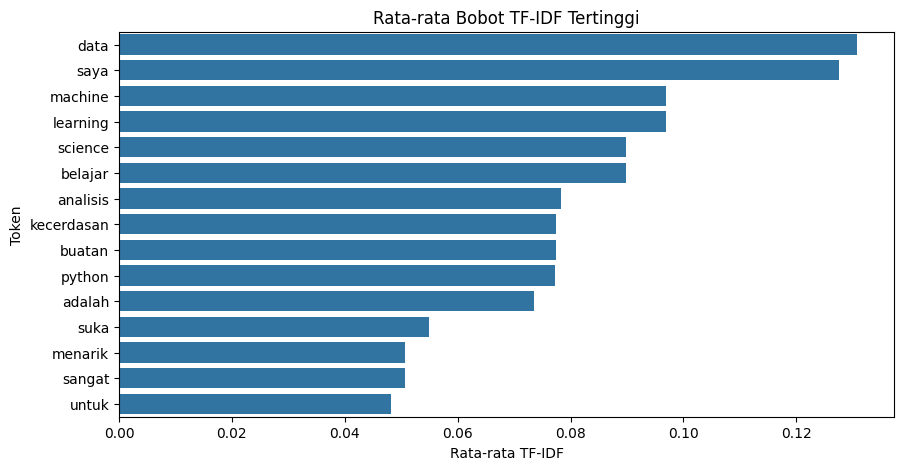

In [7]:
# Visualisasi 15 fitur TF-IDF dengan nilai rata-rata tertinggi
mean_tfidf = tfidf_table.mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 5))
sns.barplot(x=mean_tfidf.values, y=mean_tfidf.index)
plt.title('Rata-rata Bobot TF-IDF Tertinggi')
plt.xlabel('Rata-rata TF-IDF')
plt.ylabel('Token')
plt.show()

## 5. Cosine similarity

Query harus menggunakan vectorizer yang sama dengan corpus. Vectorizer hanya di-`fit` pada corpus, sedangkan query diproses dengan `transform`.

In [8]:
query = 'data'
query_vector = tfidf_vectorizer.transform([preprocess_text(query)])
scores = cosine_similarity(query_vector, X_tfidf).ravel()
ranking = np.argsort(scores)[::-1]

results = corpus[['document_id', 'text']].copy()
results['similarity'] = scores
results = results.sort_values('similarity', ascending=False).reset_index(drop=True)
print(f'Top dokumen untuk query: {query!r}')
display(results.head(5))

Top dokumen untuk query: 'data'


,document_id,text,similarity
0,1,Saya suka belajar data science.,0.362910
1,9,Belajar data science sangat menarik.,0.335578
2,3,Saya menggunakan Python untuk analisis data.,0.318143
3,4,Analisis data membantu dalam pengambilan keput...,0.291093
4,2,Python adalah bahasa pemrograman yang populer.,0.000000


In [9]:
assert X_bow.shape[0] == len(sentences)
assert X_tfidf.shape[0] == len(sentences)
assert len(scores) == len(sentences)
assert np.all(scores >= -1e-9) and np.all(scores <= 1 + 1e-9)
print('Validasi matriks dan skor similarity: PASS')

Validasi matriks dan skor similarity: PASS


## 6. Analisis hasil

BoW menghasilkan nilai frekuensi token, sedangkan TF-IDF menghasilkan bobot kepentingan token. Dokumen dengan skor cosine similarity tertinggi memiliki fitur yang paling dekat dengan query `data`.

BoW dan TF-IDF cocok sebagai baseline karena cepat dan mudah diinterpretasikan. Keterbatasannya adalah tidak memahami sinonim, urutan kata, dan konteks. Word embedding menghasilkan vektor dense yang lebih semantik, sedangkan Transformer embedding lebih kontekstual tetapi membutuhkan resource lebih besar.

Vectorizer harus di-`fit` hanya pada data training atau corpus basis pencarian. Data testing dan query cukup diproses dengan `transform` agar tidak terjadi data leakage.

## 7. Kesimpulan

Feature extraction mengubah teks menjadi fitur numerik untuk machine learning dan pencarian dokumen. BoW merupakan baseline sederhana berbasis frekuensi, sedangkan TF-IDF mempertimbangkan kelangkaan token di seluruh corpus.

Cosine similarity dapat memberi peringkat dokumen berdasarkan kemiripan dengan query. Untuk query `data`, dokumen tentang data science dan analisis data diharapkan memperoleh skor tertinggi. Pengembangan berikutnya dapat membandingkan hasil TF-IDF dengan Sentence Transformers untuk semantic search.

In [10]:
# Membuat draft analisis dan kesimpulan berdasarkan hasil eksperimen
top_document = results.iloc[0]
nonzero_bow = int((X_bow.toarray() > 0).sum())
nonzero_tfidf = int((X_tfidf.toarray() > 0).sum())

analysis = f'''
ANALISIS OTOMATIS
Eksperimen menggunakan {len(sentences)} dokumen dan menghasilkan {len(bow_features)} fitur vocabulary.
Matriks Bag of Words berukuran {X_bow.shape} dengan {nonzero_bow} nilai non-zero.
Matriks TF-IDF berukuran {X_tfidf.shape} dengan {nonzero_tfidf} nilai non-zero.
BoW menunjukkan frekuensi kemunculan token, sedangkan TF-IDF memberi bobot
lebih besar pada token yang relatif penting dan tidak terlalu umum dalam corpus.
Untuk query '{query}', dokumen dengan similarity tertinggi adalah:
'{top_document['text']}' dengan skor {top_document['similarity']:.4f}.
Hal ini menunjukkan bahwa cosine similarity menemukan dokumen yang memiliki
fitur kata paling dekat dengan query.
'''

conclusion = f'''
KESIMPULAN OTOMATIS
Feature extraction berhasil mengubah {len(sentences)} dokumen teks menjadi
representasi numerik menggunakan BoW dan TF-IDF. BoW cocok sebagai baseline
karena sederhana dan mudah diinterpretasikan, sedangkan TF-IDF lebih baik
dalam membedakan kata yang penting dari kata yang terlalu umum.

Berdasarkan cosine similarity, dokumen teratas untuk query '{query}' adalah
'{top_document['text']}' dengan skor {top_document['similarity']:.4f}.
Untuk pencarian berbasis makna yang lebih kompleks, eksperimen berikutnya
dapat membandingkan TF-IDF dengan word embedding atau Transformer embedding.
'''

print(analysis)
print(conclusion)


ANALISIS OTOMATIS
Eksperimen menggunakan 10 dokumen dan menghasilkan 41 fitur vocabulary.
Matriks Bag of Words berukuran (10, 41) dengan 58 nilai non-zero.
Matriks TF-IDF berukuran (10, 41) dengan 58 nilai non-zero.
BoW menunjukkan frekuensi kemunculan token, sedangkan TF-IDF memberi bobot
lebih besar pada token yang relatif penting dan tidak terlalu umum dalam corpus.
Untuk query 'data', dokumen dengan similarity tertinggi adalah:
'Saya suka belajar data science.' dengan skor 0.3629.
Hal ini menunjukkan bahwa cosine similarity menemukan dokumen yang memiliki
fitur kata paling dekat dengan query.


KESIMPULAN OTOMATIS
Feature extraction berhasil mengubah 10 dokumen teks menjadi
representasi numerik menggunakan BoW dan TF-IDF. BoW cocok sebagai baseline
karena sederhana dan mudah diinterpretasikan, sedangkan TF-IDF lebih baik
dalam membedakan kata yang penting dari kata yang terlalu umum.

Berdasarkan cosine similarity, dokumen teratas untuk query 'data' adalah
'Saya suka belajar data 